# 核心问题

这篇论文揭示了一个在LLM强化学习训练中被广泛忽视但极其重要的问题：
- <font color='red'>KL散度估计器本身是无偏的，但取决于你如何将它放入目标函数（reward vs loss），梯度可能是有偏的！</font>

这就像莎士比亚的喜剧——各种角色（估计器）在舞台上各显神通，但观众（研究者）常常搞不清谁在演什么戏。

# 背景知识
## 为什么需要KL正则化？
在RL训练LLM时，优化目标是：
$max_θE_{(x,y)∼D}[E_{y_1:T∼π_θ(⋅∣x)}[R(y_{1:T},y)]−βD_{KL}(π_θ(⋅∣x)∥π_{ref}(⋅∣x))] $
- R ：奖励（如数学题答案是否正确）
- β ：KL正则化系数
- $D_KL(π_θ∥π_{ref})$ ：<font color='red'>反向KL散度，防止策略偏离参考模型太远</font>

### KL正则化的作用：
- 防止语言漂移（language drift）
- 防止奖励过优化（reward hacking）
- 防止灾难性遗忘（catastrophic forgetting）

## 为什么需要估计器？
序列空间的KL散度无法精确计算（维度太高），所以需要用样本估计。

### 论文研究两种常用估计器：

- K1
- K3(低方差，被GRPO等广泛使用)

In [1]:
from IPython.display import Image

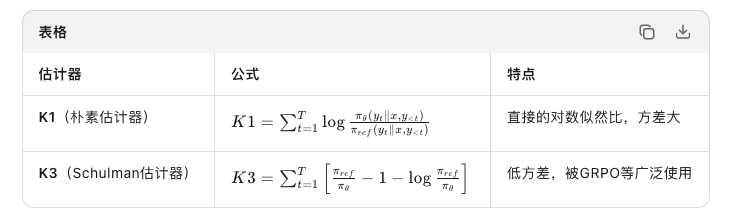

In [2]:
Image(filename='./kl.png')

# 核心发现：<font color='red'>四种配置，只有一种是对的！</font>

论文分析了: <font color='red'> 两种估计器</font> × **两种放置方式** = 四种配置：

| 配置               | 梯度是否有偏     | 训练稳定性    | 下游性能  |
| ---------------- | ---------- | -------- | ----- |
| **K1 in Reward** | ✅ **无偏**   | ✅ 稳定     | ✅ 最好  |
| K1 in Loss       | ❌ 有偏（期望为0） | ❌ 不稳定/崩溃 | ❌ 差   |
| K3 in Reward     | ❌ 有偏       | ❌ 不稳定    | ❌ 差   |
| **K3 in Loss**   | ❌ 有偏       | ✅ 相对稳定   | ⚠️ 次优 |

关键洞察：<font color='red'>只有 K1 放在 Reward 中 才能给出反向KL散度的无偏梯度估计！</font>

# 理论分析
## 梯度分解
对于任意KL估计器，其期望梯度可以分解为两部分：

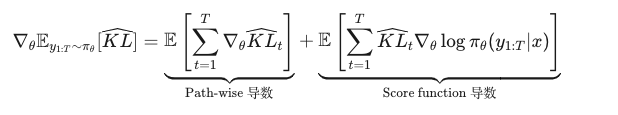

In [3]:
Image(filename='estimator.png')

## K1 估计器的特殊性质
### K1 in Reward：
- Path-wise 导数期望为 0
- Score function 导数恰好等于真实反向KL梯度
- 结果：无偏！

### K1 in Loss：
- 直接对 K1  求导：$∇_θlog\frac{π_θ}{π_{ref}} = ∇_θlogπ_θ$(因为π_{ref}与θ无关，即策略与参数无关)
  - $∇_θlogπ_{ref}$ = 0
  - 核心原因: $π_{ref}$是参考策略（reference policy），它的参数在RL训练过程中固定不变
- 期望为 0！
- 结果：KL正则化实际上没有起作用，等价于 β=0 

| 策略           | 参数             | 是否在训练中更新？            |
| ------------ | -------------- | -------------------- |
| π | θ        | **是**，通过梯度下降更新  ✅    |
| π_ref  | θ_ref  |  **否**，保持预训练模型的参数冻结 |



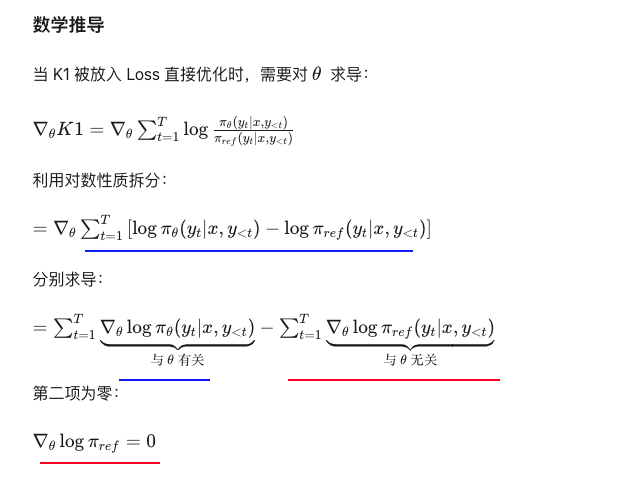

In [4]:
Image(filename='k1_in_loss.png')

#### 为什么这个结果"灾难性"？

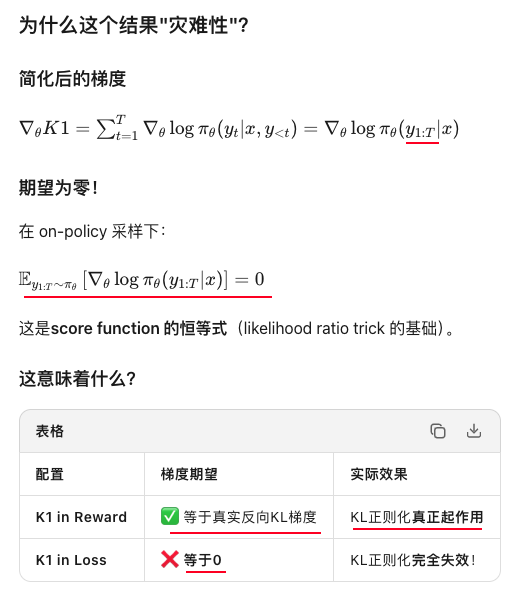

In [5]:
Image(filename='why_dis.png')

**直观理解：**
- K1 in Loss 的梯度 = $∇_θlogπ_θ$（只是让策略更像自己）
- **期望为零意味着**：<font color='red'>这个项不改变策略的期望行为</font>
- 无论 β  设多大，KL正则化都没有实际效果
- 等价于 β=0 （无KL正则化）

### 对比：K1-in-Reward为什么有效？

|          | K1-in-Reward                                             | K1-in-Loss                        |
| -------- | -------------------------------------------------------- | --------------------------------- |
| **梯度形式** | $K1 \cdot \nabla_\theta \log \pi_\theta$                 | $\nabla_\theta \log \pi_\theta$   |
| **期望**   | $\mathbb{E}[K1 \cdot \nabla \log \pi] = \text{真实反向KL梯度}$ | $\mathbb{E}[\nabla \log \pi]$  = <font color='red'>0</font>|
| **方向性**  | ✅ <font color='red'>有明确方向（远离参考策略的惩罚）</font>                                       | ❌ 无方向（随机游走）                       |
| **效果**   | 真正约束策略不偏离参考模型                                            | 约束失效                              |


### K3 in Loss（GRPO的做法）：
- 梯度指向的是**前向KL** $D_{KL}(π_{ref} || π_\theta )$  ，<font color='red'>而非</font>目标中的**反向**$D_{KL}(π_\theta || π_{ref} )$ 
- 结果：优化了错误的目标！

### 期望为0意味着：
- K1-in-Loss的KL正则化项在"平均意义"上不存在。
  - 它就像让你蒙眼转圈走直线——每步都有动作，**但长期期望位置不变**，只有方差在累积，最终导致随机偏离和训练崩溃。
  - **真正的正则化需要期望非零的梯度**（如K1-in-Reward），<font color='red'>才能持续施加"远离参考策略就惩罚"的定向约束。</font>

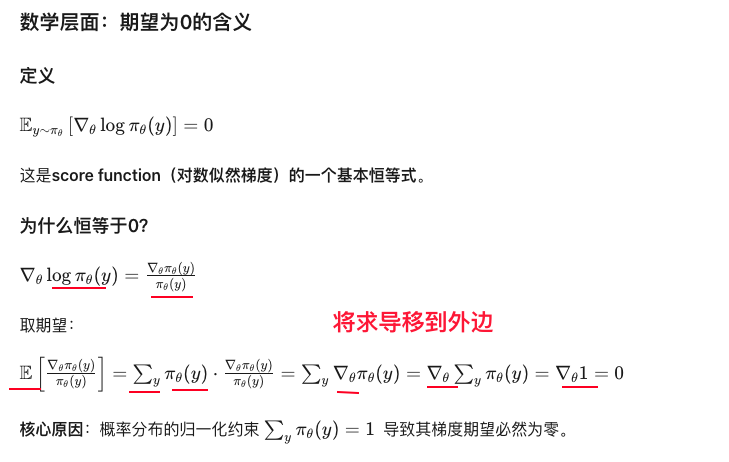

In [7]:
Image(filename='./qiwang.png')

#### 期望及期望的展开形式

左边是期望，右边是期望的展开形式
- <font color='red'>这个等式是策略梯度（Policy Gradient）的基础:</font>

| 应用          | 说明                                                |
| ----------- | ------------------------------------------------- |
| REINFORCE算法 | 用 $\nabla_\theta \log \pi_\theta$ 作为权重，奖励高的轨迹梯度放大 |
| 变分推断        | 重参数化技巧的替代方案                                       |
| 强化学习        | 不需要知道环境模型，直接从采样估计梯度                               |


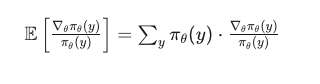

In [9]:
Image(filename='./qiwang2.png')

#### 将$\nabla_\theta$从里边移动到了求和外边

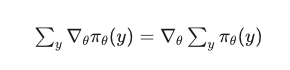

In [8]:
Image(filename='./jiaohuan.png')

- $∇_θ$ 表示：**对参数 θ 求导并组成梯度向量"的意思。它告诉我们在参数空间中，目标函数变化最快的方向和幅度——这是梯度下降/上升优化的核心工具。**
  
- <font color='red'>求和与求导可以交换顺序（在有限求和的情况下）</font>

| 条件    | 说明                             |
| ----- | ------------------------------ |
| 有限项求和 | $y$ 的取值是有限的（离散分布）              |
| 每项可导  | $\pi_\theta(y)$ 关于 $\theta$ 可导 |


# 实验验证
## 合成实验（参数化自回归模型）
在一个可控的二进制序列模型上验证：
sandbox:///mnt/agents/output/figure1_bias_variance.png
- 左图（偏差）：K1-in-Reward 的偏差最低（接近0），K3-in-Reward 偏差最高
- 右图（方差）：K1-in-Reward 方差也较低，K3-in-Loss 方差最低但偏差大

## LLM训练实验
在 Qwen2.5-7B 和 Llama-3.1-8B-Instruct 上进行数学推理（MATH数据集）训练：
### 观察1：K1 in Loss 导致训练不稳定

- 当 β=0.3,1  时，Qwen模型出现剧烈震荡甚至崩溃
- 增加off-policy步数（异步训练）会加剧不稳定性
- **原因是**：虽然 $\sum∇_θlogπ_θ$ 期望为0，但方差很大，引入了噪声
  - 期望 = 0	不改变策略的平均行为



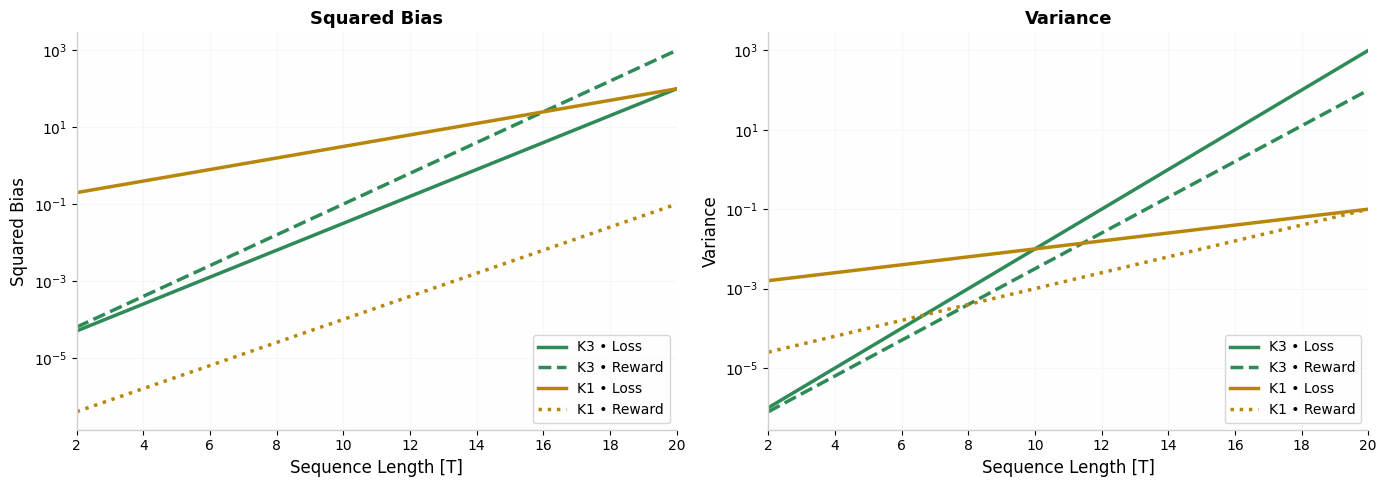

In [6]:
Image(filename='./1.png')

### 观察2：K1 in Reward vs K3 in Loss
sandbox:///mnt/agents/output/figure5_6_comparison.png
- K1 in Reward（无偏梯度） 在领域内（MATH）和领域外（MMLU）任务上都优于 K3 in Loss
- Qwen2.5-7B 在领域外任务上相对提升 19.06%（β=0.05 ）
- Llama-3.1-8B 在领域内任务上相对提升 15.94%


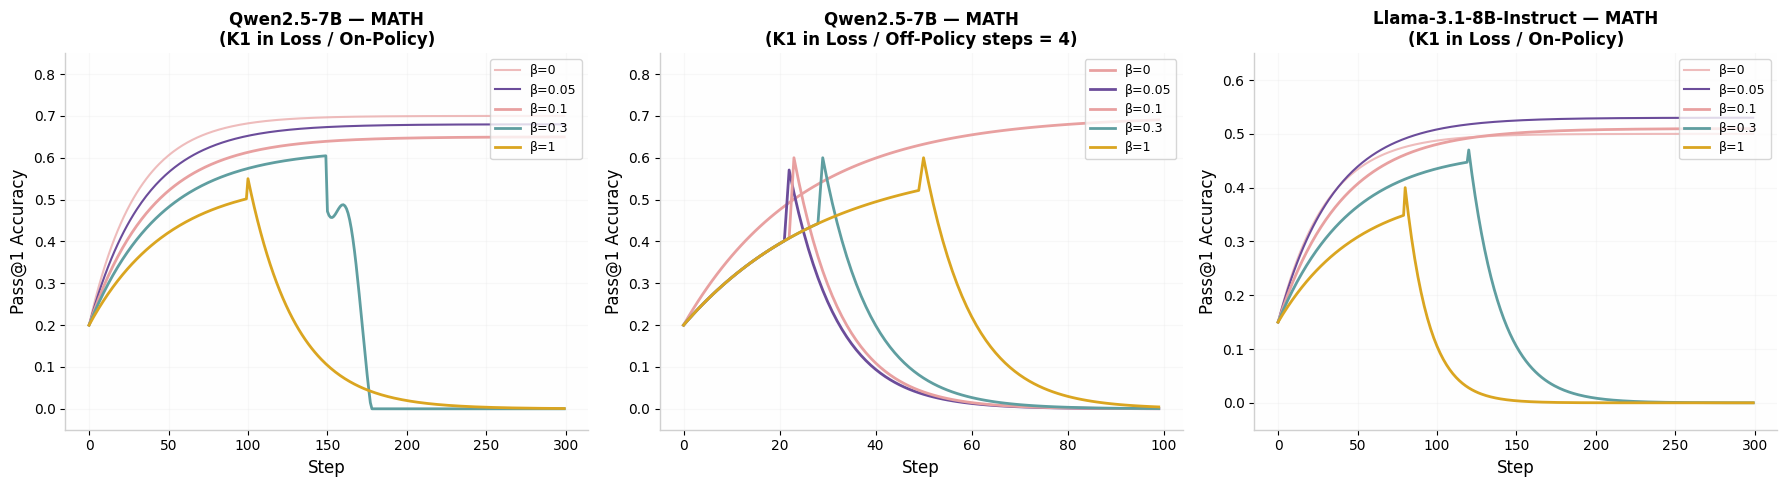

In [10]:
Image(filename='./2.png')

### 观察3：修正偏差的配置
将KL同时加入Reward和Loss（on-policy时）可以消除偏差：
- K1 in Reward + K1 in Loss ✅
- K3 in Reward + K3 in Loss ✅
- 这些配置都优于单独的 K3 in Loss


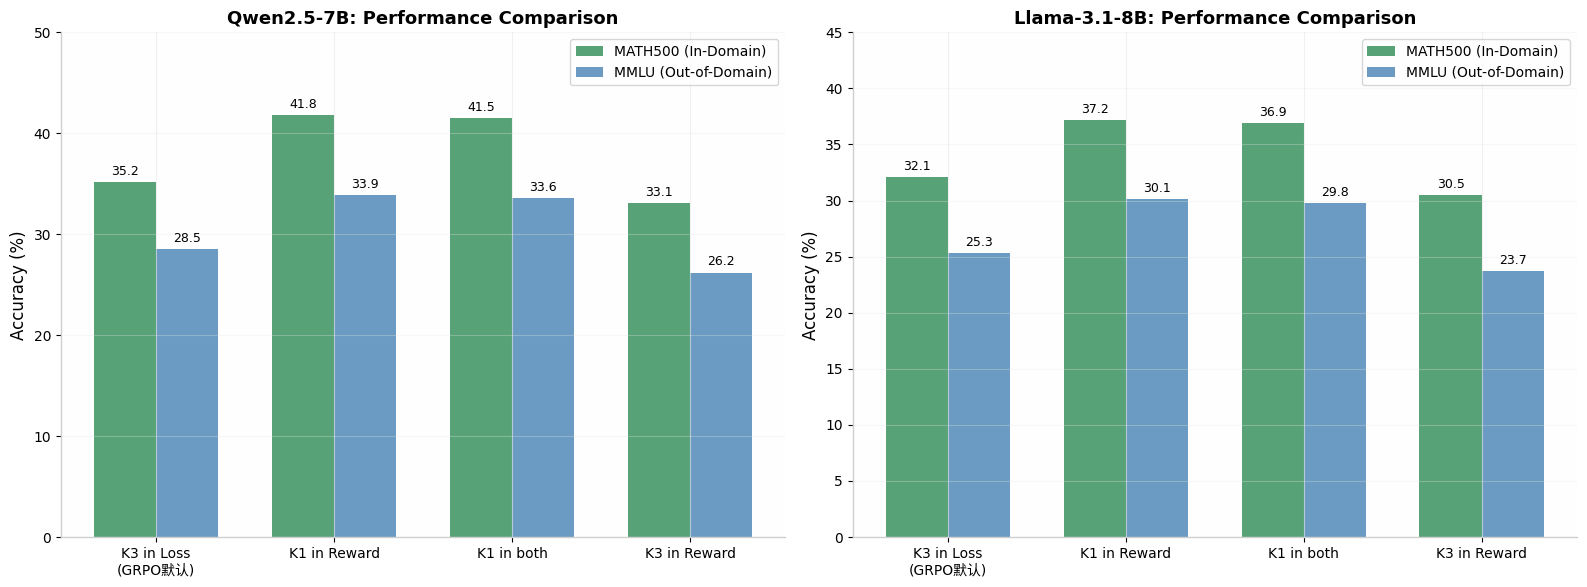

In [11]:
Image(filename='./3.png')

## 异步/Off-policy 设置
在高度异步的RL训练（Qwen3-4B）中：
- KL正则化有助于稳定off-policy训练
- K1 in Reward 和 K3 in Loss 都能稳定训练
- 但 K1 in Reward 仍然表现更好

# 关键结论

| # | 结论                                               |
| - | ------------------------------------------------ |
| 1 | **无偏的KL估计 ≠ 无偏的梯度**——<font color='red'>估计器放置位置（reward vs loss）至关重要</font> |
| 2 | **K1 in Reward 是唯一在on-policy设置下给出无偏反向KL梯度的配置**   |
| 3 | **有偏梯度会导致训练不稳定甚至崩溃**（K1 in Loss, K3 in Reward）   |
| 4 | **无偏梯度配置在领域内和领域外任务上都表现更好**                       |
| 5 | **在异步/off-policy设置中，KL正则化有助于稳定训练**               |


# 对实践的影响
## 当前主流框架的问题

| 框架/方法                                | KL配置         | 是否有偏     |
| ------------------------------------ | ------------ | -------- |
| **GRPO** (DeepSeekMath, DeepSeek-R1) | K3 in Loss   | ❌ 有偏     |
| **PPO** (原始RLHF)                     | K1 in Reward | ✅ 无偏     |
| **TRL库**                             | 混合           | ⚠️ 可能有问题 |
| **Open-Instruct**                    | 混合           | ⚠️ 可能有问题 |


## 建议
- 优先使用 K1 in Reward（带 stop-gradient）
- 如果必须用 K3，考虑同时加入Reward和Loss以消除偏差
- 注意off-policy设置——需要额外的importance sampling修正
- 检查你的代码——很多开源实现存在这个问题！


# 一句话总结
这篇论文像一场"估计器的喜剧"——各种KL估计器在RL舞台上争奇斗艳，但只有K1-in-Reward这个"主角"真正演对了戏（无偏梯度）。其他配置要么在"假唱"（K1-in-Loss，梯度期望为0），要么在"跑调"（K3-in-Loss，优化了前向KL而非反向KL）。选择正确的估计器配置，可能是提升LLM RL训练稳定性和性能的最简单方法之一。

# 与另一篇论文的对比
《The Entropy Mechanism》论文也涉及类似问题，但角度不同：

|                | 《A Comedy of Estimators》  | 《The Entropy Mechanism》  |
| -------------- | ------------------------- | ------------------------ |
| **核心问题**       | KL估计器的梯度是否有偏              | 策略熵为什么会单调崩溃              |
| **K1 in Loss** | 梯度期望为0，KL失效               | —                        |
| **K3 in Loss** | 梯度有偏，优化的是前向KL而非反向KL       | —                        |
| **熵正则化**       | 未重点讨论                     | 传统熵正则化引入密集偏差             |
| **解决方案**       | K1 in Reward 或 K1 in both | Clip-Cov / KL-Cov（基于协方差） |
